# Tutorial 6: Network Analysis

**Duration:** 20-25 minutes

This tutorial covers graph-based analysis of spatial tissue data. We'll construct networks from cell coordinates and analyze network properties to understand tissue organization.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Build cell graphs using different construction methods (proximity, k-NN, Delaunay)
- Compute centrality measures (degree, betweenness, closeness)
- Analyze clustering and connectivity
- Compute mixing patterns and assortativity
- Identify important cells (hubs, bridges)

## Prerequisites

- Tutorials 1-5 completed
- Basic understanding of graph theory concepts

## Biological Context

**Why network analysis?**
- Captures the structure of cell-cell interactions
- Identifies hub cells that connect many others
- Reveals communication pathways through tissue
- Quantifies mixing vs segregation of cell types

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spatialtissuepy import SpatialTissueData
from spatialtissuepy.network import (
    # Graph construction
    CellGraph,
    build_proximity_graph,
    build_knn_graph,
    build_delaunay_graph,
    # Centrality
    degree_centrality,
    betweenness_centrality,
    closeness_centrality,
    centrality_by_type,
    top_central_nodes,
    # Clustering
    clustering_coefficient,
    average_clustering,
    transitivity,
    n_connected_components,
    # Assortativity and mixing
    degree_assortativity,
    type_assortativity,
    attribute_mixing_matrix,
    homophily_ratio,
    neighbor_type_distribution,
    average_degree_connectivity,
    average_node_degree,
    homophily_ratio_by_cell_type,
    # Path and efficiency
    global_efficiency,
    average_shortest_path_length,
)
from spatialtissuepy.viz import (
    plot_spatial_scatter,
    plot_cell_graph,
    plot_degree_distribution,
    plot_centrality_by_type,
    plot_type_mixing_matrix,
)

np.random.seed(42)

### Create sample tissue data

In [2]:
# Create tissue with clustered tumor and infiltrating immune cells
tumor_coords = np.random.normal(loc=[500, 500], scale=100, size=(200, 2))
tumor_types = ['Tumor'] * 200

cd8_coords = np.random.normal(loc=[500, 500], scale=180, size=(80, 2))
cd8_types = ['CD8_T_cell'] * 80

stromal_coords = np.random.uniform(0, 1000, size=(100, 2))
stromal_types = ['Stromal'] * 100

macro_coords = np.random.uniform(0, 1000, size=(60, 2))
macro_types = ['Macrophage'] * 60

coordinates = np.vstack([tumor_coords, cd8_coords, stromal_coords, macro_coords])
cell_types = np.array(tumor_types + cd8_types + stromal_types + macro_types)

tissue = SpatialTissueData(coordinates=coordinates, cell_types=cell_types)
print(tissue)

SpatialTissueData
  Cells: 440
  Dimensions: 2D
  Cell types: 4
  Bounds: x=[13.0, 1054.2], y=[4.6, 996.9]


## Section 1: Graph Construction Methods

Different graph construction methods capture different aspects of spatial relationships:

| Method | Description | Use Case |
|--------|-------------|----------|
| Proximity | Connect cells within distance r | Known interaction range |
| k-NN | Connect to k nearest neighbors | Variable density tissues |
| Delaunay | Triangulation-based connectivity | Natural tessellation |
| Gabriel | Subset of Delaunay (stricter) | Less dense graphs |

In [3]:
# Build graphs using different methods
graph_proximity = CellGraph.from_spatial_data(
    tissue, method='proximity', radius=50.0
)

graph_knn = CellGraph.from_spatial_data(
    tissue, method='knn', k=6
)

graph_delaunay = CellGraph.from_spatial_data(
    tissue, method='delaunay'
)

print("Graph Statistics:")
print(f"\nProximity (r=50μm):")
print(f"  Nodes: {graph_proximity.n_nodes}, Edges: {graph_proximity.n_edges}")
print(f"  Mean degree: {average_node_degree(graph_proximity):.2f}")

print(f"\nk-NN (k=6):")
print(f"  Nodes: {graph_knn.n_nodes}, Edges: {graph_knn.n_edges}")
print(f"  Mean degree: {average_node_degree(graph_knn):.2f}")

print(f"\nDelaunay:")
print(f"  Nodes: {graph_delaunay.n_nodes}, Edges: {graph_delaunay.n_edges}")
print(f"  Mean degree: {average_node_degree(graph_delaunay):.2f}")

Graph Statistics:

Proximity (r=50μm):
  Nodes: 440, Edges: 2237
  Mean degree: 10.17

k-NN (k=6):
  Nodes: 440, Edges: 1604
  Mean degree: 7.29

Delaunay:
  Nodes: 440, Edges: 1308
  Mean degree: 5.95


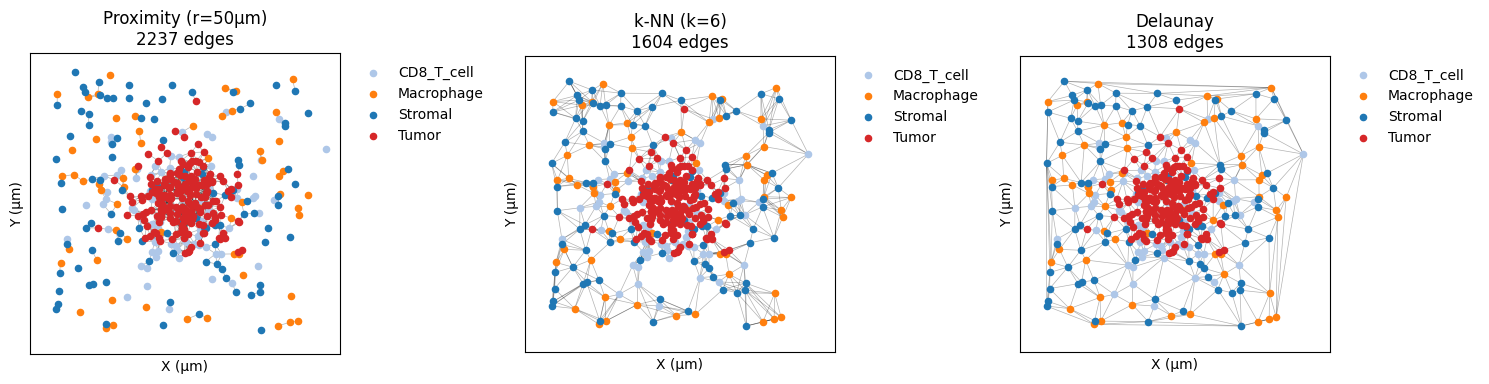

In [4]:
# Visualize the different graph structures
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (graph, title) in zip(axes, [
    (graph_proximity, 'Proximity (r=50μm)'),
    (graph_knn, 'k-NN (k=6)'),
    (graph_delaunay, 'Delaunay')
]):
    plot_cell_graph(graph, layout='spatial', ax=ax, edge_alpha=0.3)
    ax.set_title(f'{title}\n{graph.n_edges} edges')

plt.tight_layout()
plt.show()

## Section 2: Centrality Analysis

Centrality measures identify "important" nodes in the network.

### Key measures:
- **Degree centrality:** Number of connections (well-connected cells)
- **Betweenness centrality:** Frequency on shortest paths (bridge cells)
- **Closeness centrality:** Inverse of average distance (accessible cells)

In [5]:
# Use proximity graph for analysis
graph = graph_proximity

# Compute centrality measures
degree_cent = degree_centrality(graph)
between_cent = betweenness_centrality(graph)
close_cent = closeness_centrality(graph)

print("Centrality Statistics:")
print(f"\nDegree centrality:")
print(f"  Mean: {np.mean(list(degree_cent.values())):.4f}")
print(f"  Max: {max(degree_cent.values()):.4f}")

print(f"\nBetweenness centrality:")
print(f"  Mean: {np.mean(list(between_cent.values())):.4f}")
print(f"  Max: {max(between_cent.values()):.4f}")

print(f"\nCloseness centrality:")
print(f"  Mean: {np.mean(list(close_cent.values())):.4f}")
print(f"  Max: {max(close_cent.values()):.4f}")

Centrality Statistics:

Degree centrality:
  Mean: 0.0232
  Max: 0.0774

Betweenness centrality:
  Mean: 0.0054
  Max: 0.0597

Closeness centrality:
  Mean: 0.0909
  Max: 0.1727


In [6]:
# Analyze centrality by cell type
cent_by_type = centrality_by_type(graph, metric='degree')

print("Mean Degree Centrality by Cell Type:")
for ct, stats in cent_by_type.items():
    print(f"  {ct}: {stats['mean']:.4f} (std={stats['std']:.4f})")

Mean Degree Centrality by Cell Type:
  CD8_T_cell: 0.0176 (std=0.0155)
  Macrophage: 0.0061 (std=0.0088)
  Stromal: 0.0092 (std=0.0142)
  Tumor: 0.0375 (std=0.0178)


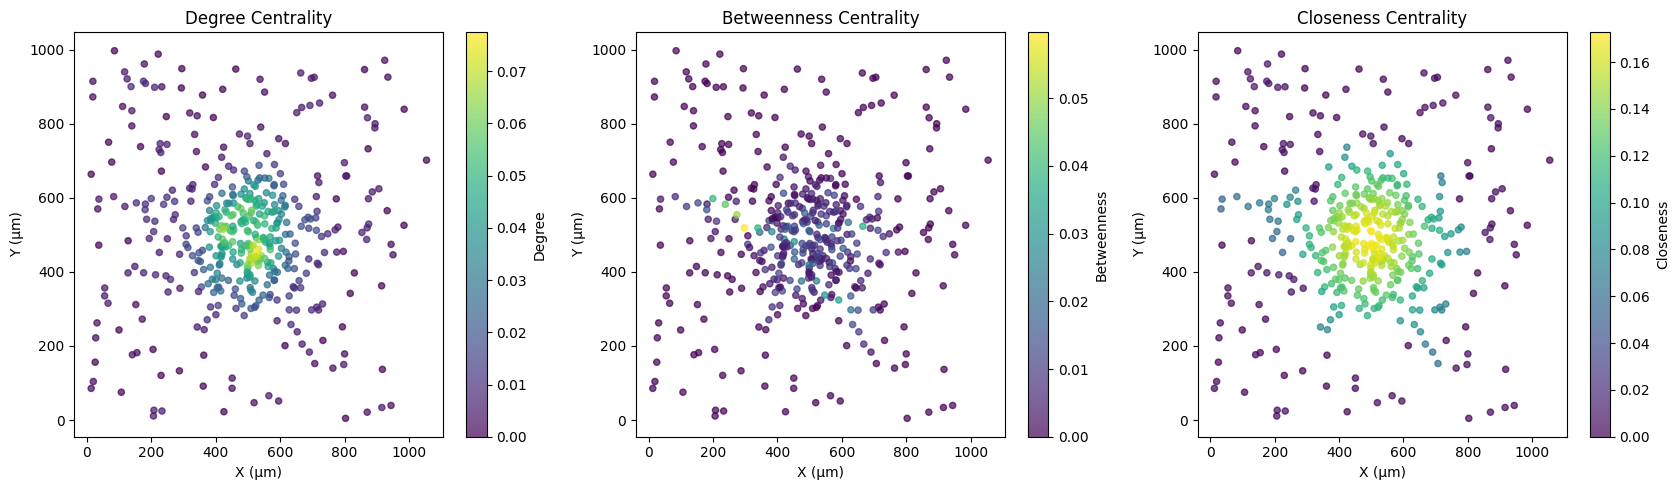

In [7]:
# Visualize centrality across the tissue
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

centralities = [
    ('Degree', degree_cent),
    ('Betweenness', between_cent),
    ('Closeness', close_cent)
]

for ax, (name, cent_dict) in zip(axes, centralities):
    values = np.array([cent_dict[i] for i in range(len(tissue.coordinates))])
    scatter = ax.scatter(
        tissue.coordinates[:, 0],
        tissue.coordinates[:, 1],
        c=values,
        cmap='viridis',
        s=20,
        alpha=0.7
    )
    plt.colorbar(scatter, ax=ax, label=name)
    ax.set_title(f'{name} Centrality')
    ax.set_xlabel('X (μm)')
    ax.set_ylabel('Y (μm)')

plt.tight_layout()
plt.show()

In [8]:
# Find top central nodes
top_degree = top_central_nodes(graph, metric='degree', n=10)
top_between = top_central_nodes(graph, metric='betweenness', n=10)

print("Top 10 Nodes by Degree Centrality:")
for node in top_degree:
    node_id = node['node']
    cell_type = node['cell_type']
    score = node['centrality']
    print(f"  Node {node_id} ({cell_type}): {score:.4f}")

print("\nTop 10 Nodes by Betweenness Centrality:")
for node in top_between:
    node_id = node['node']
    cell_type = node['cell_type']
    score = node['centrality']
    print(f"  Node {node_id} ({cell_type}): {score:.4f}")

Top 10 Nodes by Degree Centrality:
  Node 171 (Tumor): 0.0774
  Node 25 (Tumor): 0.0729
  Node 345 (Stromal): 0.0706
  Node 38 (Tumor): 0.0683
  Node 116 (Tumor): 0.0683
  Node 138 (Tumor): 0.0683
  Node 166 (Tumor): 0.0683
  Node 184 (Tumor): 0.0683
  Node 275 (CD8_T_cell): 0.0683
  Node 169 (Tumor): 0.0661

Top 10 Nodes by Betweenness Centrality:
  Node 118 (Tumor): 0.0597
  Node 384 (Macrophage): 0.0505
  Node 37 (Tumor): 0.0443
  Node 260 (CD8_T_cell): 0.0398
  Node 71 (Tumor): 0.0381
  Node 280 (Stromal): 0.0368
  Node 258 (CD8_T_cell): 0.0333
  Node 264 (CD8_T_cell): 0.0307
  Node 30 (Tumor): 0.0303
  Node 267 (CD8_T_cell): 0.0278


## Section 3: Clustering and Connectivity

Clustering measures quantify local connectivity (triangles, cliques).

In [9]:
# Compute clustering metrics
local_clustering = clustering_coefficient(graph)
avg_clustering = average_clustering(graph)
trans = transitivity(graph)
n_components = n_connected_components(graph)

print("Clustering and Connectivity:")
print(f"  Average clustering coefficient: {avg_clustering:.4f}")
print(f"  Transitivity (global clustering): {trans:.4f}")
print(f"  Number of connected components: {n_components}")

Clustering and Connectivity:
  Average clustering coefficient: 0.4914
  Transitivity (global clustering): 0.5945
  Number of connected components: 70


In [10]:
# Clustering by cell type
print("\nMean Clustering Coefficient by Cell Type:")
for ct in tissue.cell_types_unique:
    mask = tissue.cell_types == ct
    indices = np.where(mask)[0]
    ct_clustering = [local_clustering[i] for i in indices if i in local_clustering]
    if ct_clustering:
        print(f"  {ct}: {np.mean(ct_clustering):.4f}")


Mean Clustering Coefficient by Cell Type:
  CD8_T_cell: 0.5256
  Macrophage: 0.3604
  Stromal: 0.3307
  Tumor: 0.5974


In [11]:
# Network efficiency
efficiency = global_efficiency(graph)
print(f"\nGlobal efficiency: {efficiency:.4f}")
print("(Higher = information flows efficiently through the network)")


Global efficiency: 0.1243
(Higher = information flows efficiently through the network)


## Section 4: Mixing Patterns and Assortativity

These metrics describe how cell types mix in the network:
- **Type assortativity:** Do cells prefer connecting to same type (+) or different types (-)?
- **Mixing matrix:** Edge counts between all type pairs

In [12]:
# Type assortativity
type_assort = type_assortativity(graph)
degree_assort = degree_assortativity(graph)

print("Assortativity Measures:")
print(f"  Type assortativity: {type_assort:.4f}")
print(f"  Degree assortativity: {degree_assort:.4f}")
print("\nInterpretation:")
print(f"  Type: {'Same types connect' if type_assort > 0 else 'Different types connect'}")
print(f"  Degree: {'Hubs connect to hubs' if degree_assort > 0 else 'Hubs connect to non-hubs'}")

Assortativity Measures:
  Type assortativity: 0.1503
  Degree assortativity: 0.8233

Interpretation:
  Type: Same types connect
  Degree: Hubs connect to hubs


In [13]:
# Attribute mixing matrix
mixing = attribute_mixing_matrix(graph)

print("Type-Type Mixing Matrix (edge counts):")
print(mixing)

Type-Type Mixing Matrix (edge counts):
            CD8_T_cell  Macrophage   Stromal     Tumor
CD8_T_cell    0.020295    0.010802  0.022913  0.127987
Macrophage    0.010802    0.004910  0.013748  0.018003
Stromal       0.022913    0.013748  0.010802  0.074304
Tumor         0.127987    0.018003  0.074304  0.428478


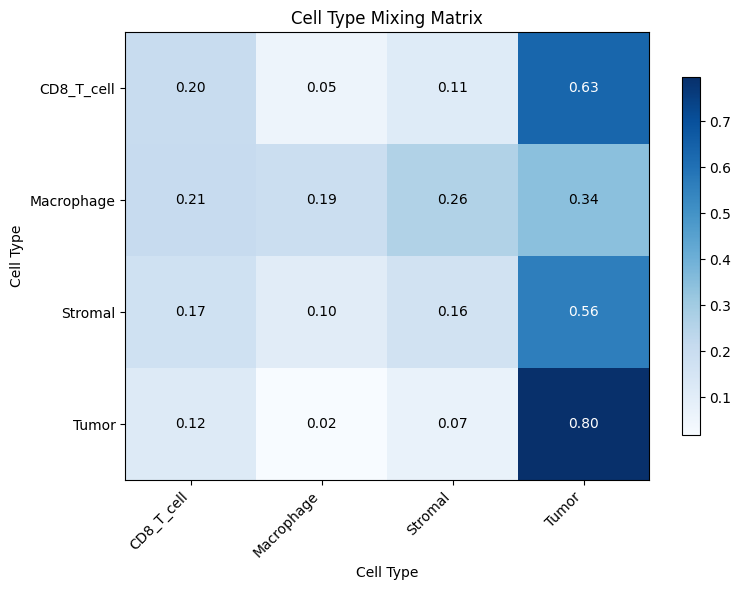

In [14]:
# Visualize mixing matrix
fig, ax = plt.subplots(figsize=(8, 6))
plot_type_mixing_matrix(graph, ax=ax)
ax.set_title('Cell Type Mixing Matrix')
plt.tight_layout()
plt.show()

In [15]:
# Homophily analysis
homophily = homophily_ratio_by_cell_type(graph)

print("Homophily Ratio by Cell Type:")
print("(Fraction of edges to same type)")
for ct, ratio in homophily.items():
    interpretation = "clustered" if ratio > 0.5 else "mixing"
    print(f"  {ct}: {ratio:.3f} ({interpretation})")

Homophily Ratio by Cell Type:
(Fraction of edges to same type)
  CD8_T_cell: 0.201 (mixing)
  Macrophage: 0.188 (mixing)
  Stromal: 0.163 (mixing)
  Tumor: 0.796 (clustered)


In [24]:
# Neighbor type distribution
neighbor_dist = neighbor_type_distribution(graph, cell_type='Tumor')

print("\nNeighbor Type Distribution:")
print("(For the 'Tumor' cell type, what types are its neighbors and in what proportion?)\n")
for focal_type, dist in neighbor_dist.items():
    print(f"{focal_type}:{dist:.2f}")


Neighbor Type Distribution:
(For the 'Tumor' cell type, what types are its neighbors and in what proportion?)

CD8_T_cell:0.12
Macrophage:0.02
Stromal:0.07
Tumor:0.80


## Section 5: Degree Distribution

In [28]:
# Degree distribution analysis
degrees = [graph.G.degree(n) for n in graph.G.nodes()]

print("Degree Statistics:")
print(f"  Mean: {np.mean(degrees):.2f}")
print(f"  Median: {np.median(degrees):.2f}")
print(f"  Std: {np.std(degrees):.2f}")
print(f"  Min: {min(degrees)}, Max: {max(degrees)}")

Degree Statistics:
  Mean: 10.17
  Median: 7.00
  Std: 9.07
  Min: 0, Max: 34


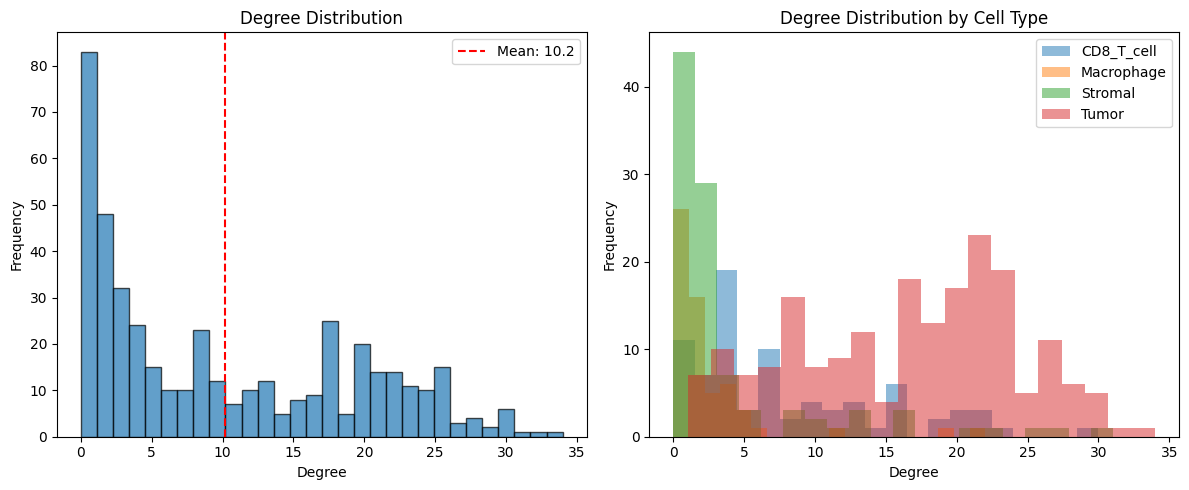

In [29]:
# Plot degree distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(degrees, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(degrees), color='red', linestyle='--', label=f'Mean: {np.mean(degrees):.1f}')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Degree Distribution')
axes[0].legend()

# By cell type
for ct in tissue.cell_types_unique:
    mask = tissue.cell_types == ct
    ct_degrees = [degrees[i] for i in np.where(mask)[0]]
    axes[1].hist(ct_degrees, bins=20, alpha=0.5, label=ct)
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Degree Distribution by Cell Type')
axes[1].legend()

plt.tight_layout()
plt.show()

## Exercise: Compare Graph Methods

1. **Effect of radius:** Build proximity graphs with different radii (30, 50, 100 μm). How does this affect centrality patterns?

2. **Hub identification:** Find the top 5 hub cells (highest degree) for each cell type. Are they at specific locations?

3. **Type segregation:** Compare type assortativity between proximity and k-NN graphs. Which shows more segregation?

In [19]:
# Your code here


## Summary

In this tutorial, you learned:

- **Graph construction:** Different methods (proximity, k-NN, Delaunay) for creating cell graphs
- **Centrality analysis:** Identifying important cells using degree, betweenness, and closeness
- **Clustering metrics:** Measuring local connectivity patterns
- **Mixing patterns:** Quantifying cell type segregation vs integration
- **Degree distributions:** Understanding network topology

**Key insights:**
- Centrality reveals cells in key structural positions
- Type assortativity quantifies homophily in cell mixing
- Network efficiency describes information flow potential

## Next Steps

- **Tutorial 7: Spatial LDA** - Topic modeling for neighborhood patterns
- **Tutorial 8: Topology/Mapper** - Topological data analysis